# 04 — Lead-Lag Analysis

For each (market, crypto asset, jump definition) triple:
1. Cross-correlation function (CCF) with confidence bands
2. Granger causality test (with Bonferroni correction)
3. Lead-lag regression by forward horizon
4. Three placebo tests

**Decision gate**: If no definition shows statistically significant lead-lag → hypothesis rejected, stop.

In [1]:
import sys
sys.path.append('..')

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.lead_lag import (
    compute_ccf, run_granger, lead_lag_regression,
    placebo_time_shuffle, placebo_random_jumps, placebo_cross_asset,
    bonferroni_correct,
)
from src.plots import plot_ccf, plot_lead_lag_regression

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

raw_dir  = Path('../data/raw')
proc_dir = Path('../data/processed')
LAGS = [-60, -30, -10, -5, -1, 0, 1, 5, 10, 30, 60]

# Load BTC returns as primary crypto asset
btc = pd.read_parquet(raw_dir / 'crypto' / 'crypto_1m_BTCUSDT.parquet')
btc = btc.set_index('timestamp_utc').sort_index()
btc_ret = btc['log_ret']

eth = pd.read_parquet(raw_dir / 'crypto' / 'crypto_1m_ETHUSDT.parquet')
eth = eth.set_index('timestamp_utc').sort_index()
eth_ret = eth['log_ret']

print('Crypto data loaded.')

Crypto data loaded.


In [2]:
DEFINITIONS = ['D1', 'D2', 'D3', 'D4']
signals_dict = {}
for defn in DEFINITIONS:
    path = proc_dir / f'jump_signals_{defn}.parquet'
    if path.exists():
        signals_dict[defn] = pd.read_parquet(path)
        print(f'{defn}: {signals_dict[defn].shape[1]} markets')

markets = list(signals_dict.get('D1', pd.DataFrame()).columns)

D1: 53 markets
D2: 53 markets
D3: 53 markets
D4: 53 markets


## 1. Cross-Correlation Function (CCF)

In [3]:
ccf_results = {}  # {(market, defn): ccf_df}

for defn, sig_df in signals_dict.items():
    for market in sig_df.columns:
        signal = sig_df[market].dropna()
        if (signal != 0).sum() < 10:
            continue

        event_signal = signal.fillna(0)
        ret = btc_ret.reindex(event_signal.index).fillna(0)

        ccf = compute_ccf(event_signal, ret, lags=LAGS)
        ccf_results[(market, defn)] = ccf

print(f'Computed CCF for {len(ccf_results)} (market, definition) pairs')

Computed CCF for 142 (market, definition) pairs


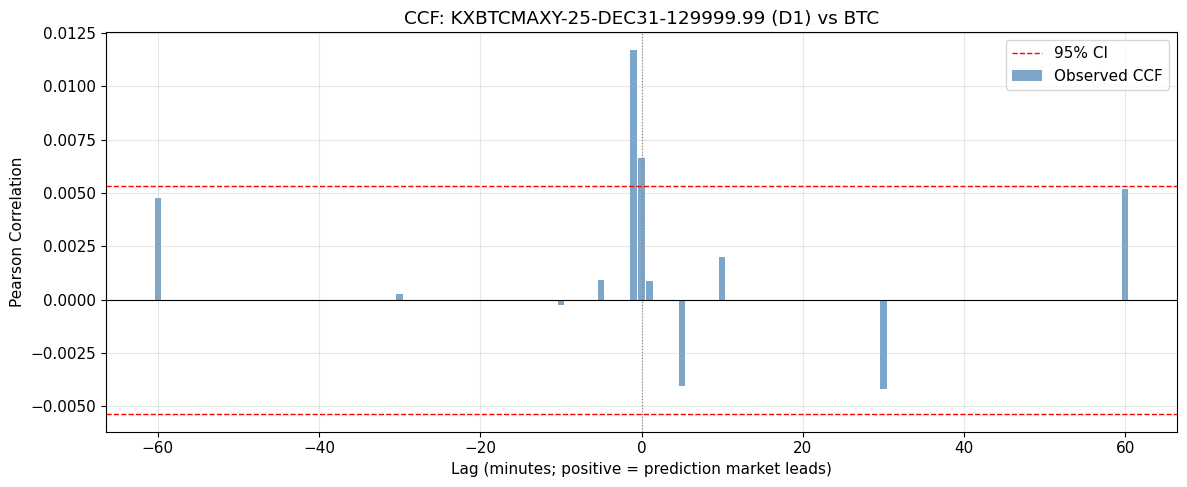

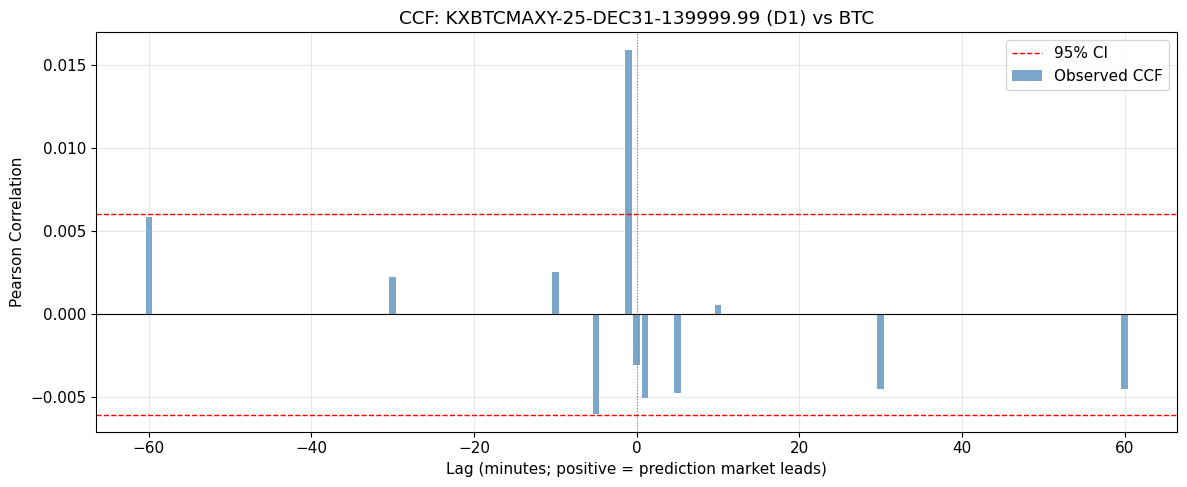

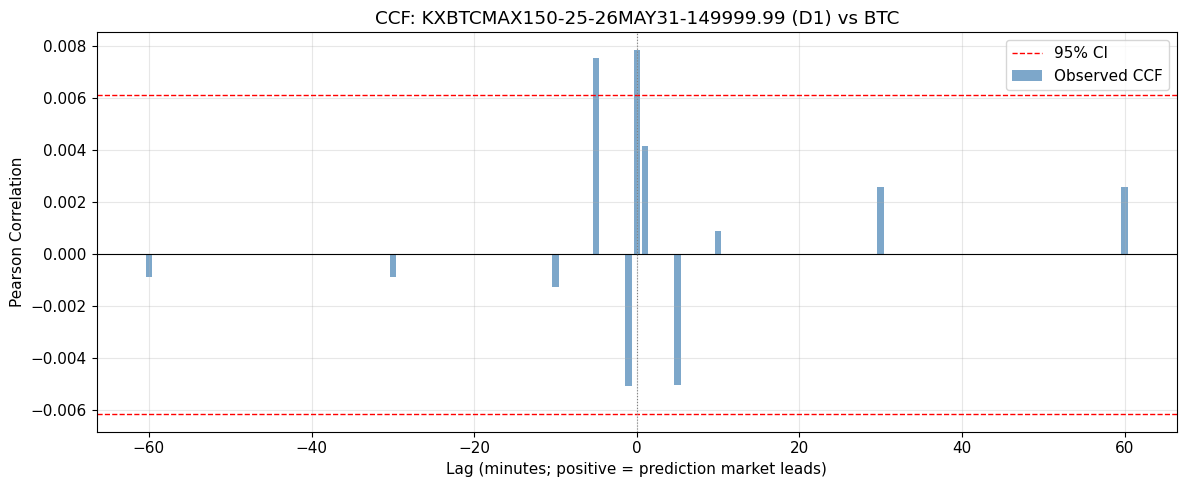

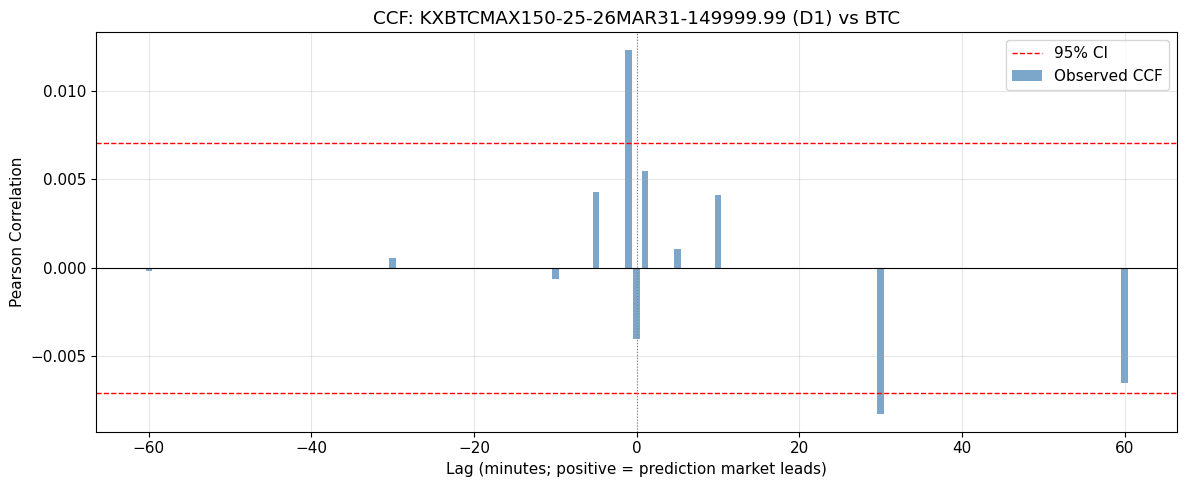

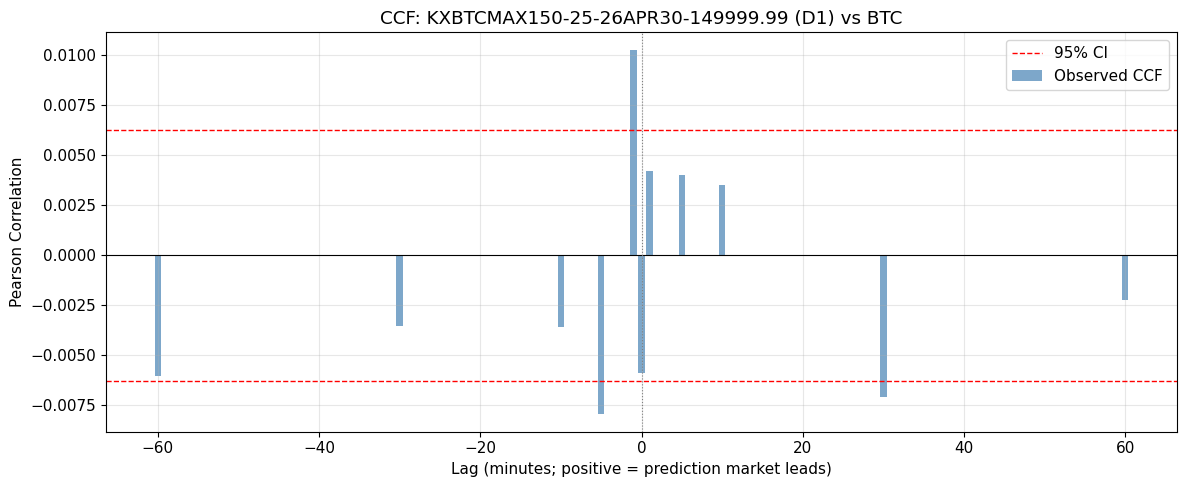

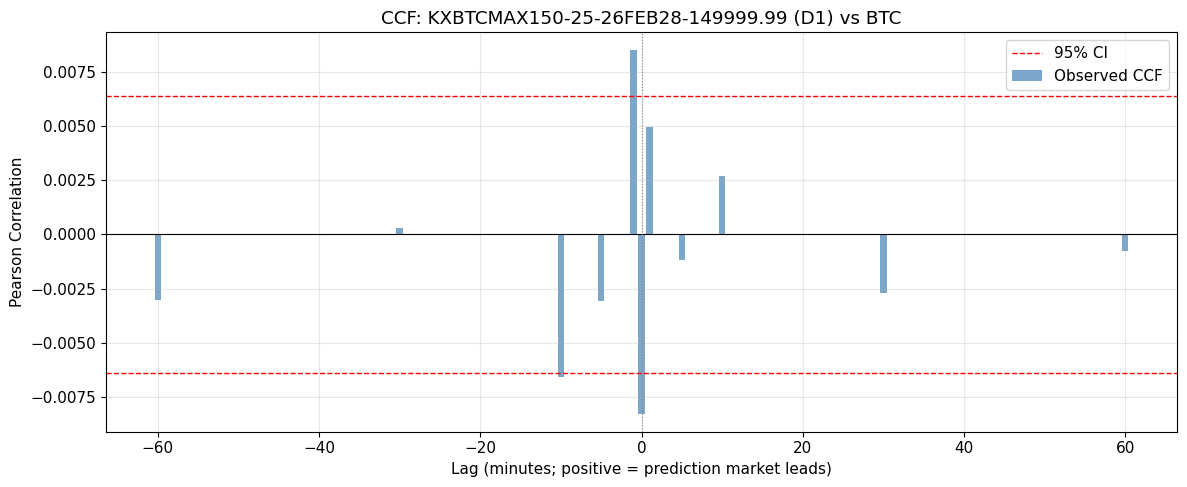

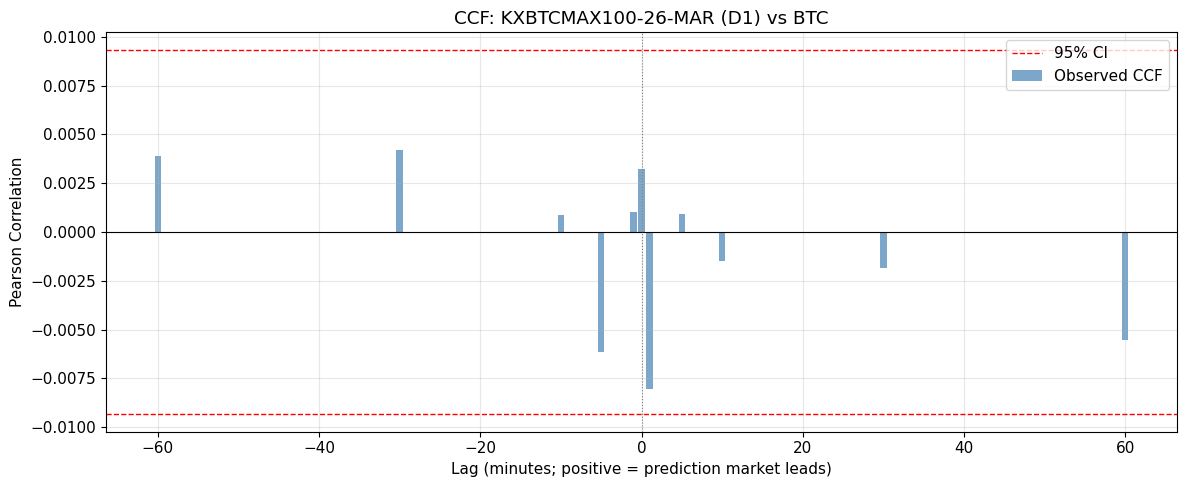

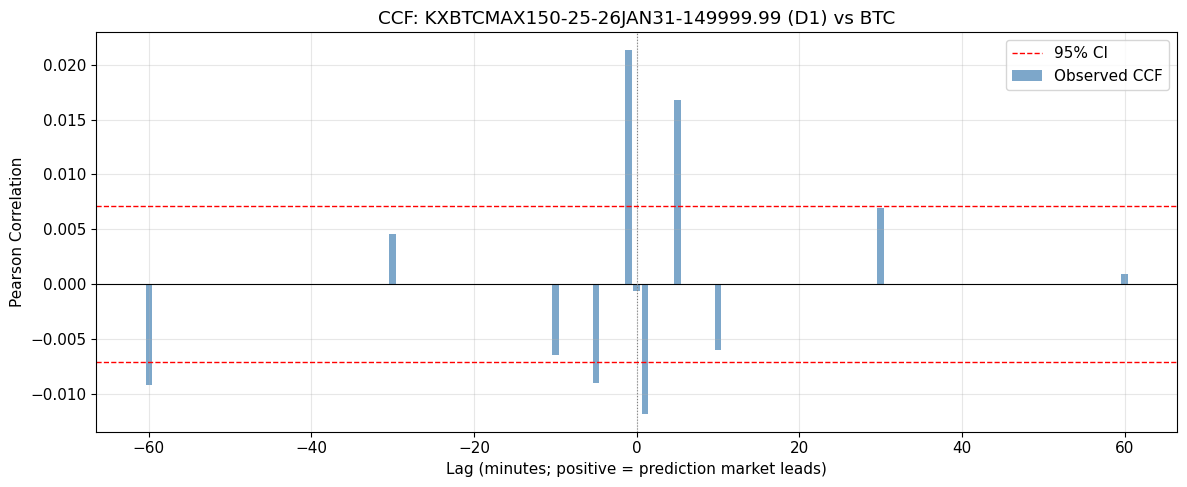

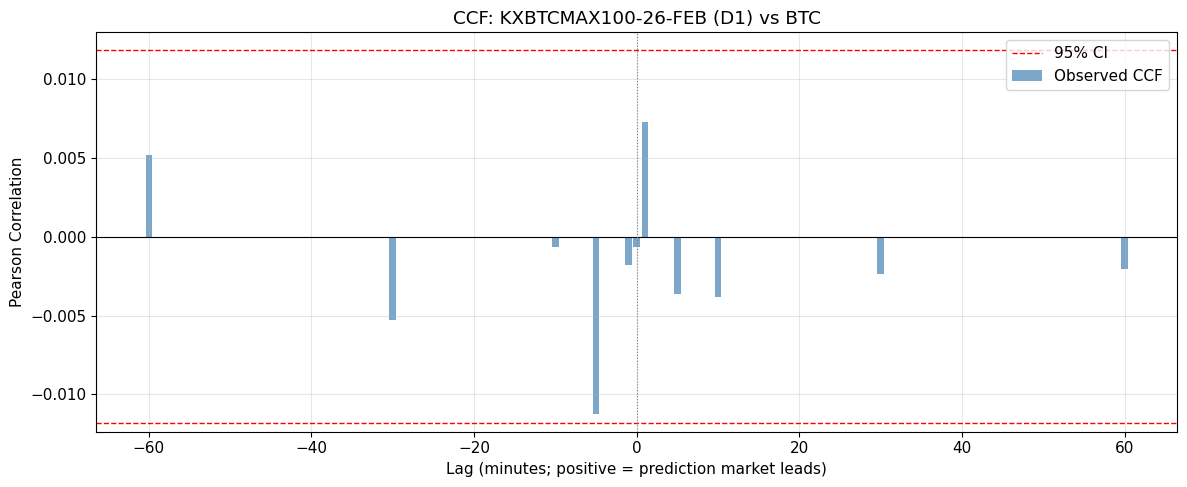

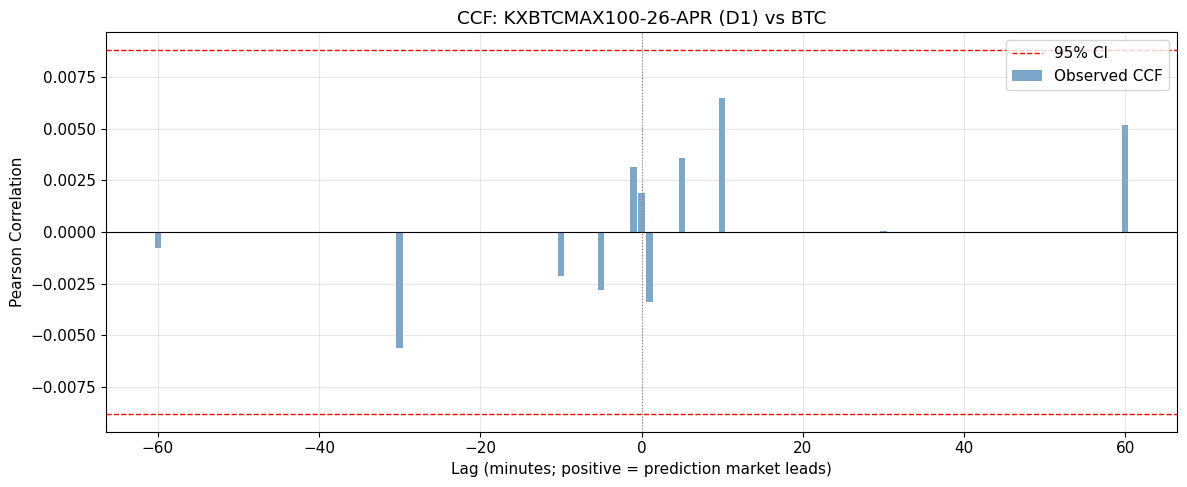

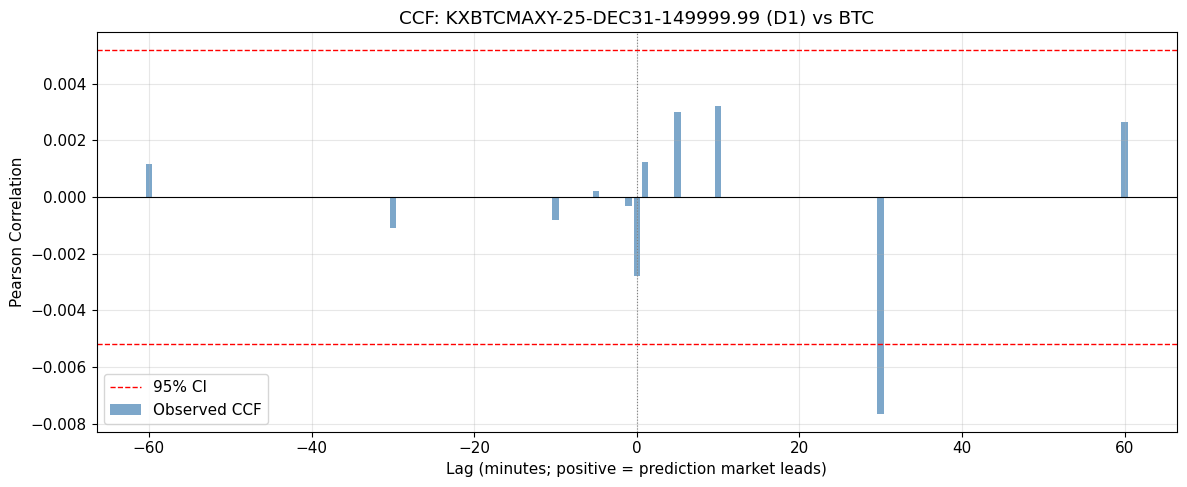

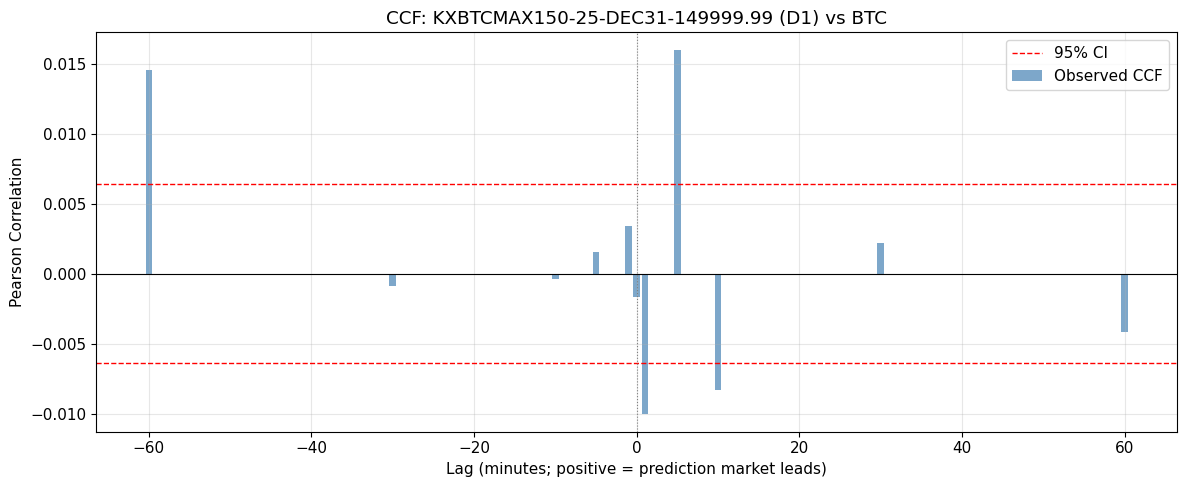

In [4]:
# Plot CCF for each market × definition
for (market, defn), ccf in list(ccf_results.items())[:12]:  # first 12 to avoid overload
    fig = plot_ccf(ccf, title=f'CCF: {market} ({defn}) vs BTC')
    plt.show()
    plt.close()

## 2. Granger Causality

In [5]:
granger_results = []
n_tests = len(markets) * len(signals_dict)  # for Bonferroni correction

for defn, sig_df in signals_dict.items():
    for market in sig_df.columns:
        signal = sig_df[market].dropna()
        if (signal != 0).sum() < 30:
            continue

        event_signal = signal.fillna(0)
        ret = btc_ret.reindex(event_signal.index).fillna(0)

        try:
            gc = run_granger(event_signal, ret, maxlag=30)
            min_p = gc['p_value_f'].min()
            best_lag = gc.loc[gc['p_value_f'].idxmin(), 'lag']

            granger_results.append({
                'market': market,
                'definition': defn,
                'min_p_raw': min_p,
                'best_lag': best_lag,
                'min_p_bonferroni': min(min_p * n_tests, 1.0),
            })
        except Exception as e:
            pass  # skip markets with insufficient variation

gc_df = pd.DataFrame(granger_results)
gc_df['significant_raw'] = gc_df['min_p_raw'] < 0.05
gc_df['significant_bonferroni'] = gc_df['min_p_bonferroni'] < 0.05

print('=== Granger Causality Results ===')
print(gc_df.sort_values('min_p_raw').to_string(index=False))
print(f"\nSignificant (raw p<0.05): {gc_df['significant_raw'].sum()} pairs")
print(f"Significant (Bonferroni): {gc_df['significant_bonferroni'].sum()} pairs")

/Users/kianjagtiani/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/kianjagtiani/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/kianjagtiani/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/kianjagtiani/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/kianjagtiani/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/kianjagtiani/Library/Py

=== Granger Causality Results ===
                          market definition    min_p_raw  best_lag  min_p_bonferroni  significant_raw  significant_bonferroni
KXBTCMAX150-25-26JAN31-149999.99         D4 1.512371e-30        23      3.206227e-28             True                    True
    KXBTCMAXY-25-DEC31-129999.99         D4 1.806607e-26        29      3.830007e-24             True                    True
KXBTCMAX150-25-26FEB28-149999.99         D4 1.929253e-24        29      4.090016e-22             True                    True
    KXBTCMAXY-25-DEC31-139999.99         D4 1.073728e-21        29      2.276303e-19             True                    True
    KXBTCMAXY-25-DEC31-129999.99         D1 6.041315e-19        29      1.280759e-16             True                    True
KXBTCMAX150-25-26FEB28-149999.99         D1 6.810304e-19        29      1.443784e-16             True                    True
KXBTCMAX150-25-26MAY31-149999.99         D1 3.816073e-15         7      8.090075e-13

## 3. Lead-Lag Regression by Horizon

Running lead-lag regression for best pair: KXBTCMAX150-25-26JAN31-149999.99 / D4
 horizon_min      beta    t_stat  p_value       r2  n_obs
           1  0.000437  1.420393 0.164599 0.304482     37
          10 -0.001193 -0.942853 0.352408 0.245014     37
          30 -0.000710 -1.177286 0.247257 0.050823     37
          60  0.000734  0.708210 0.483642 0.048819     37
         240  0.000957  0.515448 0.609576 0.012890     37
        1440  0.005203  1.112469 0.273741 0.047741     37


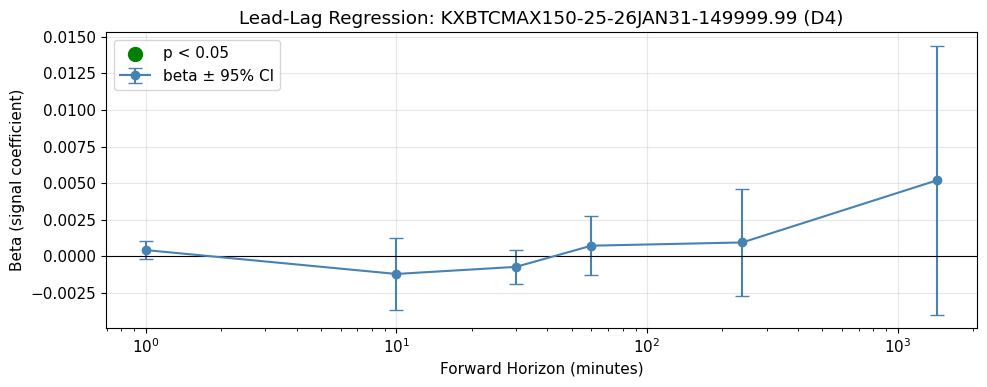

In [6]:
HORIZONS = [1, 10, 30, 60, 240, 1440]

# Run for the most promising (market, definition) pair based on Granger results
if not gc_df.empty:
    best_pair = gc_df.sort_values('min_p_raw').iloc[0]
    market = best_pair['market']
    defn   = best_pair['definition']
    print(f'Running lead-lag regression for best pair: {market} / {defn}')

    signal = signals_dict[defn][market].dropna()
    ret    = btc_ret.reindex(signal.index).fillna(0)

    reg = lead_lag_regression(signal, ret, horizons=HORIZONS)
    print(reg.to_string(index=False))

    fig = plot_lead_lag_regression(reg, title=f'Lead-Lag Regression: {market} ({defn})')
    plt.show()

## 4. Placebo Tests

Running placebo tests for KXBTCMAX150-25-26JAN31-149999.99 / D4 ...


KeyError: 'null_p5'

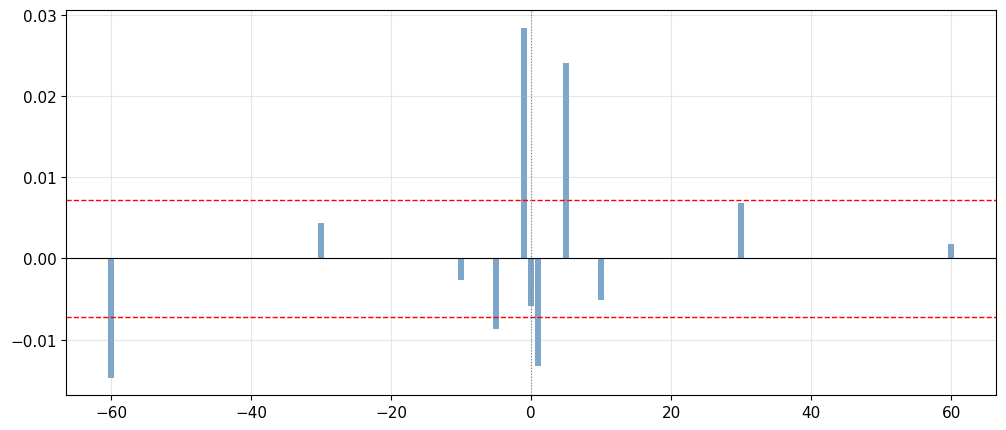

In [7]:
# Use the best pair from Granger for placebo tests
if not gc_df.empty:
    signal = signals_dict[defn][market].dropna()
    event_signal = signal.fillna(0)
    ret = btc_ret.reindex(event_signal.index).fillna(0)

    print(f'Running placebo tests for {market} / {defn} ...')

    # Placebo 1: Time shuffle
    shuffle_null = placebo_time_shuffle(signal, ret, n_simulations=200, lags=LAGS)
    real_ccf = ccf_results.get((market, defn))
    if real_ccf is not None:
        fig = plot_ccf(real_ccf, placebo_df=shuffle_null,
                       title=f'CCF vs Time-Shuffle Null: {market} ({defn})')
        plt.show()

    # Placebo 2: Random jumps
    rand_null = placebo_random_jumps(signal, ret, n_simulations=200, lags=LAGS)
    print('\nRandom jump null (5th-95th pct of correlation):')
    print(rand_null.to_string(index=False))

    # Placebo 3: Cross-asset specificity (BTC signal should predict BTC more than ETH)
    eth_ret_aligned = eth_ret.reindex(event_signal.index).fillna(0)
    cross = placebo_cross_asset(signal, ret, eth_ret_aligned, lags=LAGS)
    print('\nCross-asset check (corr_target = BTC, corr_other = ETH):')
    print(cross[['lag_min', 'corr_target', 'corr_other', 'corr_diff']].to_string(index=False))

## Decision Gate

Assess the results and decide whether to proceed.

In [ ]:
print('=== DECISION GATE ===')

if gc_df.empty:
    print('STOP: No Granger results — insufficient data.')
elif gc_df['significant_raw'].any():
    sig_pairs = gc_df[gc_df['significant_raw']]
    print(f'PROCEED: {len(sig_pairs)} (market, definition) pairs show significant lead-lag (raw p<0.05).')
    print('Best pairs:')
    print(sig_pairs.sort_values('min_p_raw')[['market', 'definition', 'min_p_raw', 'best_lag']].to_string(index=False))
    if gc_df['significant_bonferroni'].any():
        print('Some pairs survive Bonferroni correction — strong evidence.')
    else:
        print('NOTE: No pairs survive Bonferroni — evidence is weak, proceed with caution.')
else:
    print('STOP: No statistically significant lead-lag found at p<0.05 for any pair.')
    print('Hypothesis is rejected. Do not proceed to backtesting.')